# TP3 - Análisis de Sentimiento sobre Tweets (Sentiment140)
## Notebook 3 — Análisis de Errores del Modelo Elegido
### Diplomatura IA - UP
### Alumno: Gonzalez Marta Elizabeth
### Mes: Julio26
En el Notebook 2 ya se entrenaron y evaluaron los 4 modelos (TextBlob, Naive Bayes, Regresión Logística, Regresión Logística + FE) sobre train y test, y se eligió el mejor según F1 macro en test.

Este notebook toma ese modelo ya elegido y analiza **por qué** se equivoca cuando se equivoca, usando **similitud coseno** para encontrar qué tweets de train son más parecidos a los que el modelo clasificó mal en test.

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack, csr_matrix

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (7,5)

train = pd.read_csv('../data/processed/split_train.csv')
test = pd.read_csv('../data/processed/split_test.csv')

with open('../data/processed/tfidf_vectorizer_mega.pkl', 'rb') as f:
    tfidf = pickle.load(f)
with open('../data/processed/scaler_features.pkl', 'rb') as f:
    scaler = pickle.load(f)
with open('../data/processed/modelo_final_elegido.pkl', 'rb') as f:
    elegido = pickle.load(f)

nombre_modelo, modelo_final = elegido['nombre'], elegido['modelo']
print(f'Modelo elegido (del Notebook 2): {nombre_modelo}')

FEATURE_COLS = [
    'n_chars', 'n_words', 'avg_word_len', 'n_exclamation', 'n_question',
    'n_uppercase_words', 'n_elongated', 'n_pos_emoticons', 'n_neg_emoticons',
    'n_mentions_count', 'n_hashtags_count', 'n_lex_pos', 'n_lex_neg', 'lex_pos_neg_diff',
]


Modelo elegido (del Notebook 2): Regresión Logística + FE


## 1. Reconstrucción de las matrices para el modelo elegido

In [2]:
X_train_tfidf = tfidf.transform(train['clean_text'])
X_test_tfidf = tfidf.transform(test['clean_text'])

if nombre_modelo == 'Regresión Logística + FE':
    X_train_feat = scaler.transform(train[FEATURE_COLS])
    X_test_feat = scaler.transform(test[FEATURE_COLS])
    X_train_final = hstack([X_train_tfidf, csr_matrix(X_train_feat)])
    X_test_final = hstack([X_test_tfidf, csr_matrix(X_test_feat)])
else:
    X_train_final, X_test_final = X_train_tfidf, X_test_tfidf

if modelo_final is not None:
    pred_test = modelo_final.predict(X_test_final)
else:
    from textblob import TextBlob
    def _pred(t):
        pol = TextBlob(t).sentiment.polarity
        return 4 if pol > 0.1 else (0 if pol < -0.1 else 2)
    pred_test = test['text'].apply(_pred).values

test_df = test.copy()
test_df['pred'] = pred_test
print(f'Accuracy en test: {(test_df["target"]==test_df["pred"]).mean():.2%}')


Accuracy en test: 80.69%


## 2. Similitud coseno para interpretar errores

Para los tweets de test mal clasificados, buscamos los tweets de train más parecidos (por similitud coseno de sus vectores TF-IDF).

In [3]:
errores = test_df[test_df['target'] != test_df['pred']]
print(f'Errores en test: {len(errores)} / {len(test_df)} ({len(errores)/len(test_df):.1%})')

if len(errores) > 0 and modelo_final is not None:
    idx_ejemplos = errores.index[:5]
    sims = cosine_similarity(X_test_tfidf[idx_ejemplos], X_train_tfidf)

    for i, idx in enumerate(idx_ejemplos):
        row = test_df.loc[idx]
        top3 = sims[i].argsort()[::-1][:3]
        print(f"\nTweet mal clasificado (real={row['target']}, predicho={row['pred']}): '{row['text'][:100]}'")
        for t in top3:
            print(f"   sim={sims[i][t]:.2f} | target={train.loc[t,'target']} | {train.loc[t,'text'][:80]}")


Errores en test: 92269 / 477819 (19.3%)

Tweet mal clasificado (real=0, predicho=4): '... gravity doesn't cover n70me '
   sim=0.79 | target=0 | I have gravity 
   sim=0.72 | target=0 | @shan1392 I miss Gravity! 
   sim=0.69 | target=4 | Yay Gravity werkt 

Tweet mal clasificado (real=0, predicho=4): '@laureeeennnn If only I read this 5 hours ago Lauren lol! I have absolutely positively no idea! I ha'
   sim=0.42 | target=4 | Absolutely positively LOVES deep talks.  &lt;3
   sim=0.35 | target=4 | Seen on friend's t-shirt: &quot;FedSex: When you absolutely, positively have to 
   sim=0.33 | target=4 | @MP34 You have no idea 

Tweet mal clasificado (real=0, predicho=4): '@zachcumer Tucson. There are more people here than in LA right now.  Fly down! You have thirty minut'
   sim=0.64 | target=0 | In thirty minutes 
   sim=0.62 | target=0 | Work in thirty minutes. 
   sim=0.45 | target=0 | Thirty minutes to go... I am so tired. 

Tweet mal clasificado (real=4, predicho=0): 'I am soo tired 

## 3. Distribución de errores por clase real

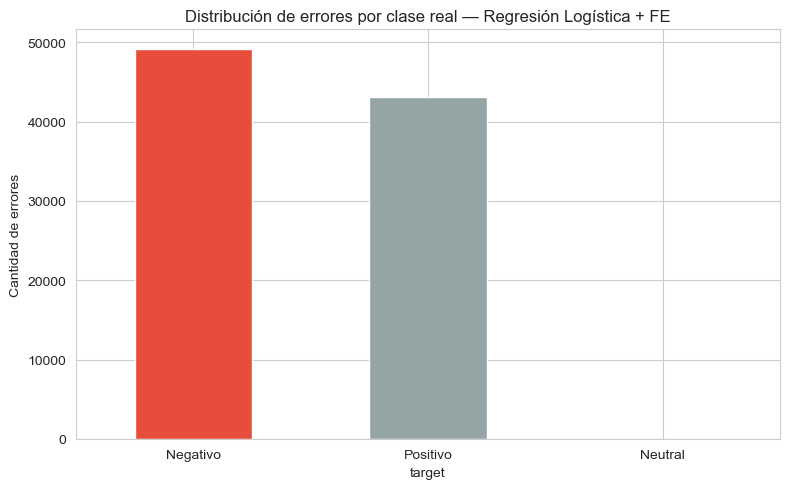

target
Negativo     20.6
Positivo     18.0
Neutral     100.0
Name: count, dtype: float64


In [5]:
fig, ax = plt.subplots(figsize=(8,5))
errores_por_clase = errores['target'].map({0:'Negativo', 2:'Neutral', 4:'Positivo'}).value_counts()
errores_por_clase.plot(kind='bar', ax=ax, color=['#e74c3c','#95a5a6','#2ecc71'])
ax.set_title(f'Distribución de errores por clase real — {nombre_modelo}')
ax.set_ylabel('Cantidad de errores')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs_nb3_errores_por_clase.png', dpi=110, bbox_inches='tight')
plt.show()

print((errores_por_clase / test_df['target'].map({0:'Negativo',2:'Neutral',4:'Positivo'}).value_counts() * 100).round(1))


**Observación esperable:** la clase neutral debería concentrar la mayor *proporción* de errores, no se visualiza por la escala.

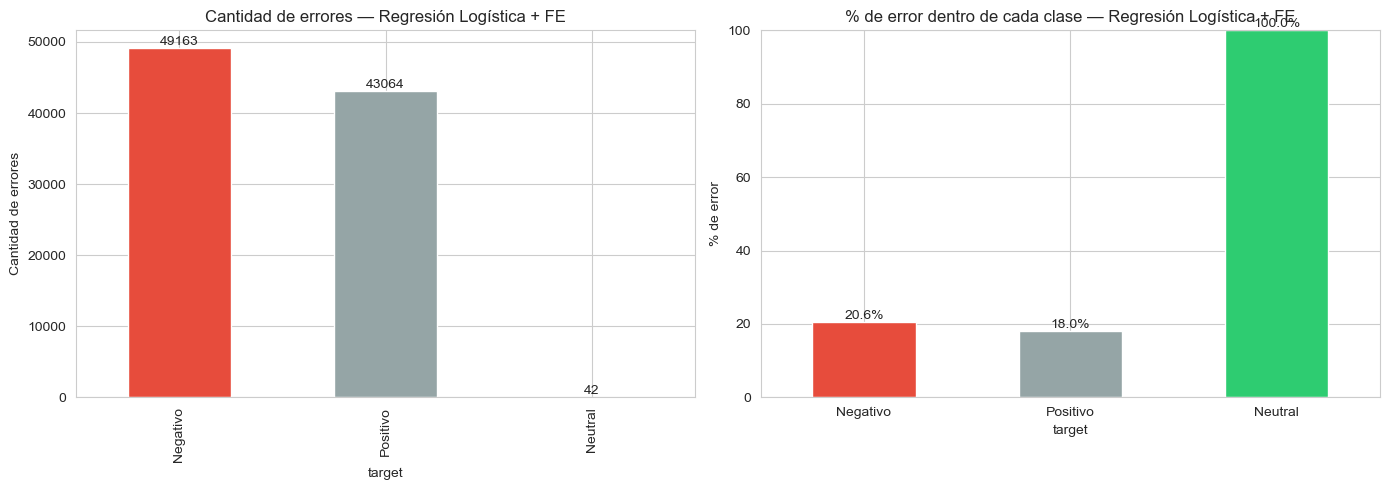

target
Negativo     20.6
Positivo     18.0
Neutral     100.0
Name: count, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

errores_por_clase = errores['target'].map({0:'Negativo', 2:'Neutral', 4:'Positivo'}).value_counts()
total_por_clase = test_df['target'].map({0:'Negativo', 2:'Neutral', 4:'Positivo'}).value_counts()
porcentaje_error = (errores_por_clase / total_por_clase * 100).round(1)

# Panel 1: cantidad absoluta de errores (con etiquetas de valor, para que se vea aunque la barra sea chica)
errores_por_clase.plot(kind='bar', ax=axes[0], color=['#e74c3c','#95a5a6','#2ecc71'])
axes[0].set_title(f'Cantidad de errores — {nombre_modelo}')
axes[0].set_ylabel('Cantidad de errores')
for i, v in enumerate(errores_por_clase):
    axes[0].text(i, v, str(v), ha='center', va='bottom')

# Panel 2: porcentaje de error dentro de cada clase (acá se ve claro el problema del neutral)
porcentaje_error.plot(kind='bar', ax=axes[1], color=['#e74c3c','#95a5a6','#2ecc71'])
axes[1].set_title(f'% de error dentro de cada clase — {nombre_modelo}')
axes[1].set_ylabel('% de error')
axes[1].set_ylim(0, 100)
for i, v in enumerate(porcentaje_error):
    axes[1].text(i, v, f'{v}%', ha='center', va='bottom')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('outputs_nb3_errores_por_clase.png', dpi=110, bbox_inches='tight')
plt.show()

print(porcentaje_error)

Nota: en este grafico se aprecia mejor la cantidad de errores por clase.

## 4. Resumen — Notebook 3

1. Se tomó el modelo ya elegido en el Notebook 2 y se interpretaron sus errores con similitud coseno.
2. Se identificó qué tweets de train son más parecidos a los casos mal clasificados.
3. Se analizó la distribución de errores por clase real.

**Continúa en `04_predicciones.ipynb`.**